**Tutorial**

## **Bayesian optimization from scratch**
Tutorial provided by Pascal Friederich (pascal.friederich@kit.edu)

We only need numpy and matplotlib for this tutorial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

We also need a ground truth function ("nature").

In reality, this would be an API to your experiment, to which you pass parameters and you receive measurement data of your objective function.

In [ ]:
def ground_truth(x):
    gt = 1.6*np.exp(-1.2*(x - 1.3)**2) + 2.4*np.exp(-0.9*(x - 3.7)**2)
    return(gt)

Let's get some numerical representation of the ground truth function for plotting.

In reality, this is not available!

In [ ]:
n = 200
gt_x = np.linspace(0, 5, n).reshape(-1, 1)
gt_f = ground_truth(gt_x)

Let's also generate some initial measurements to start the Bayesian optimization process.

In [ ]:
data_x = np.array([1.1, 1.8, 2.9])
data_f = ground_truth(data_x)

Let's plot everything to see what's going on.

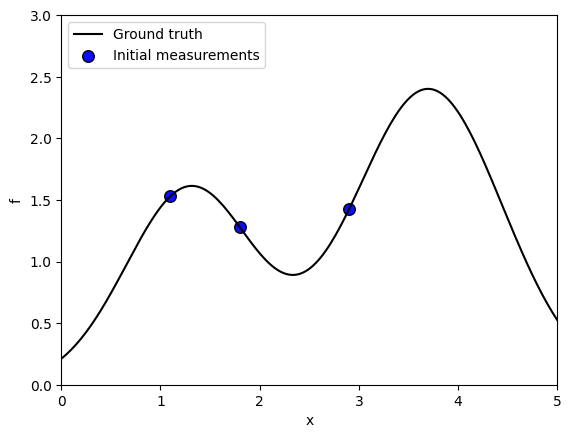

In [ ]:
plt.figure()
plt.plot(gt_x, gt_f, "k-", label = "Ground truth")
plt.scatter(data_x, data_f, marker = "o", s = 70.0, edgecolor="k", facecolor="b", alpha = 0.95, label = "Initial measurements")
plt.xlabel("x")
plt.ylabel("f")
plt.xlim([0, 5])
plt.ylim([0, 3])
plt.legend(loc="upper left")
plt.show()

Okay, let's start with Bayesian optimization.

The core is the Gaussian process surrogate model, so let's first implement a kernel ...

In [ ]:
def kernel(a, b):
    sqdist = np.sum(a**2, 1).reshape(-1, 1) + np.sum(b**2, 1) - 2*np.dot(a, b.T)
    k = np.exp(-0.5*sqdist)
    return(k)

... and now let's implement the Gaussian process itself.

It needs a training and a prediction function.

Remember the main functions of Gaussian process predictions, given the kernel evaluatons $K$.

$\mu_{*}=K_{*}^{\top}K^{-1}f$

$\sigma_{*}=K_{**}-K_{*}^{\top}K^{-1}K_{*}$


In [ ]:
class gp:
    def __init__(self, kernel):
        self.kernel = kernel

    def train(self, X, f):
        self.X = X
        self.f = f
        self.K = self.kernel(self.X, self.X)
        self.Kinv = np.linalg.inv(self.K + 1e-6*np.eye((len(X))))

    def predict(self, X_pred):
        Ks = self.kernel(self.X, X_pred)
        Kss = self.kernel(X_pred, X_pred)
        mu_s = Ks.T.dot(self.Kinv).dot(self.f)
        cov_s = Kss - Ks.T.dot(self.Kinv).dot(Ks)
        mu = mu_s.ravel()
        uncertainty = np.sqrt(np.diag(cov_s))
        return(mu, uncertainty)

Let's test the Gaussian process model on the initial data.

In [ ]:
gp_model = gp(kernel)
gp_model.train(data_x.reshape(-1, 1),
               data_f.reshape(-1, 1))

model_mean, model_uncertainty = gp_model.predict(gt_x)

We will need to plot everything many times (in each iteration during Bayesian optimization), so let's write a function for plotting.

In [ ]:
def plot(gt_x, gt_f, data_x, data_f, model_mean, model_uncertainty, ac=None, x_next=None, ac_next=None):
  plt.figure()
  plt.plot(gt_x, gt_f, "k-", label = "Ground truth")
  plt.scatter(data_x, data_f, marker = "o", s = 70.0, edgecolor="k", facecolor="b", alpha = 0.95, label = "Initial measurements")
  plt.plot(gt_x.ravel(), model_mean, label = 'GP Mean', linewidth = 1, color = "b")
  plt.fill_between(gt_x.ravel(), model_mean + model_uncertainty, model_mean - model_uncertainty, alpha = 0.3, edgecolor = "k", zorder = 2)
  plt.xlabel("x")
  plt.ylabel("f")
  plt.xlim([0, 5])
  plt.ylim([0, 3])
  plt.legend(loc="upper left")
  plt.show()

  if ac is not None:
    plt.figure(figsize=(6.4, 1.5))
    plt.plot(gt_x, ac, "r-", label = "Acquisiton function")
    plt.scatter([x_next], [ac_next], c="r", s=30, marker="o", label="Maximum")
    plt.plot([x_next, x_next], [0, ac_next], "k--")
    plt.xlim([0, 5])
    plt.ylim([0, 1.1*ac_next])
    plt.xlabel("x")
    plt.ylabel("Informativeness")
    plt.legend(loc="upper left")
    plt.show()

Let's test the plotting function with the initial Gaussian process model.

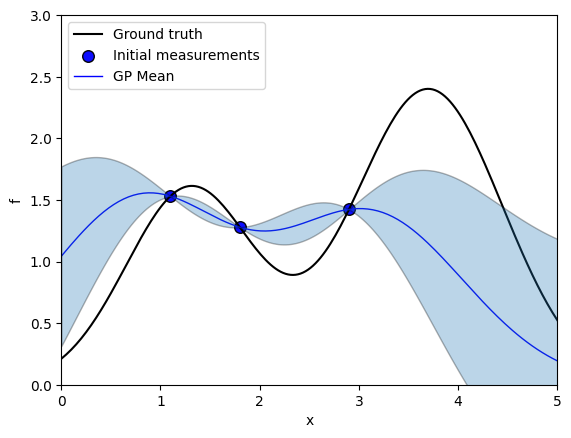

In [ ]:
plot(gt_x, gt_f, data_x, data_f, model_mean, model_uncertainty)

The second ingredient for Bayesian optimization is the acquisition function which measures the "informativeness" of possible next measurements, to select the most informative next measurement.

In [ ]:
def acquisition_function_upper_confidence_bound(mu, uncertainty):
    # define the acquistion function
    ac = mu + uncertainty
    return(ac)

def select_experiment(gt_x, ac):
    # select the best next experiment (which has the highest acquisiton function value)
    x_next = gt_x[np.argmax(ac)]
    ac_next = np.max(ac)
    return(x_next, ac_next)

Okay, we have everything we need now.

Let's implement the Bayesian optimization loop!

In every iteration, we ...

1.   evaluate the acquistion function
2.   select the most informative next datapoint
3.   "run the experiment"
4.   plot the results
5.   add the new datapoint to the training data
6.   retrain the Gaussian process model

Iteration 1 of 6: New point: [0.35175879] [0.54399953]


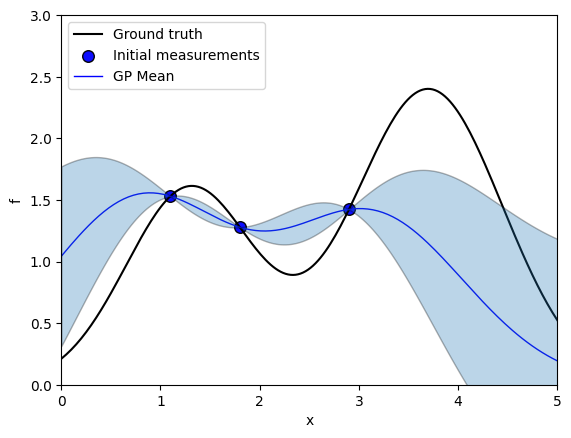

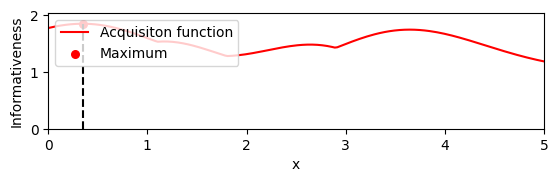

Iteration 2 of 6: New point: [3.69346734] [2.40156205]


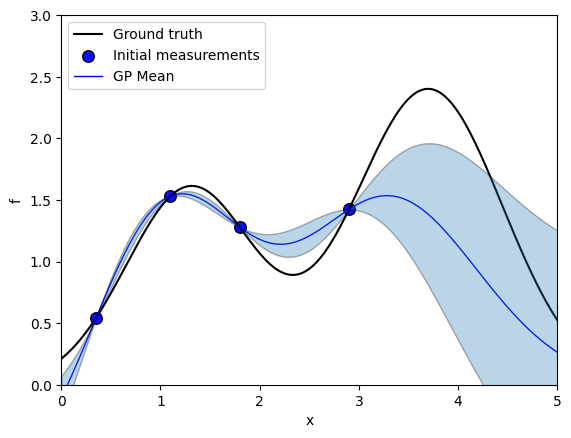

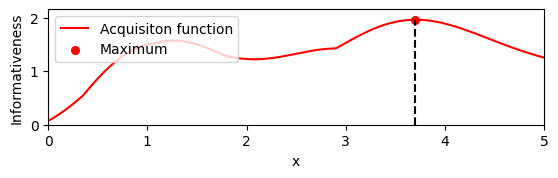

Iteration 3 of 6: New point: [4.17085427] [1.965952]


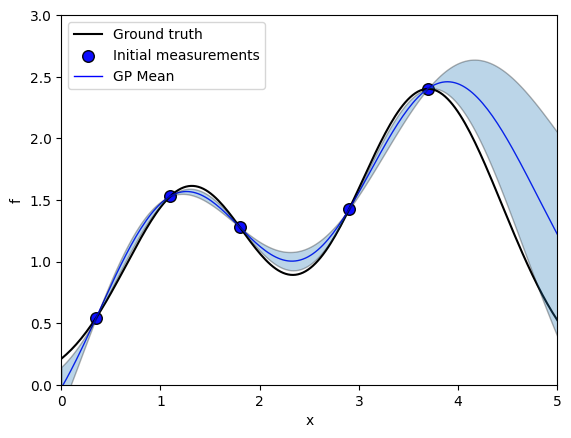

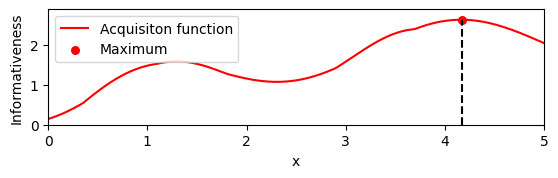

Iteration 4 of 6: New point: [3.71859296] [2.40068423]


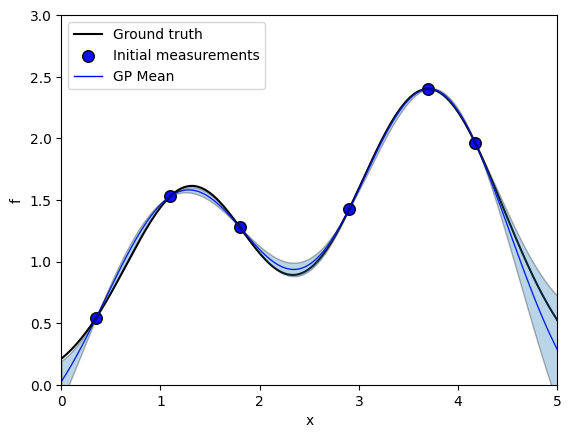

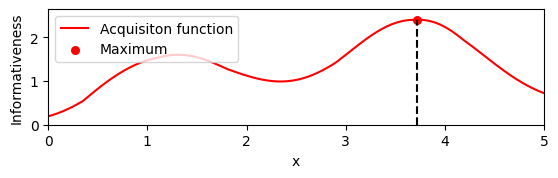

Iteration 5 of 6: New point: [3.69346734] [2.40156205]


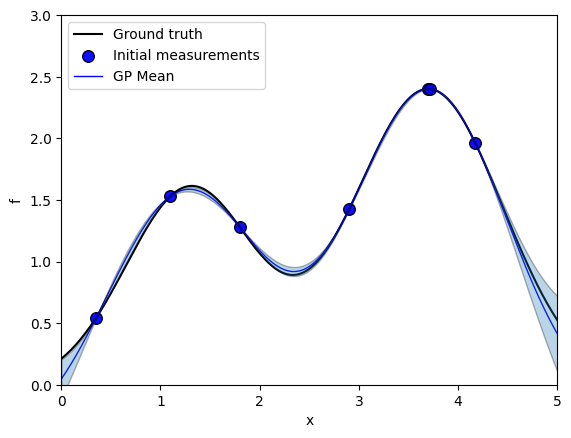

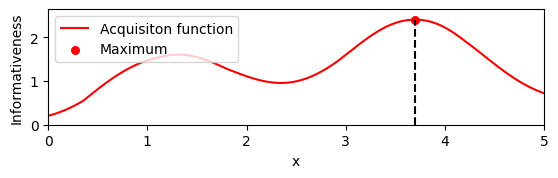

Iteration 6 of 6: New point: [3.69346734] [2.40156205]


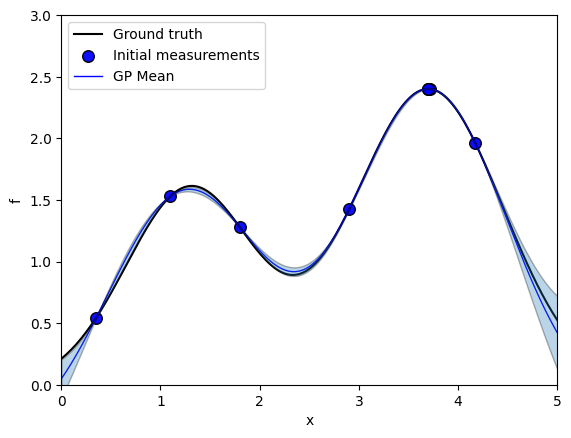

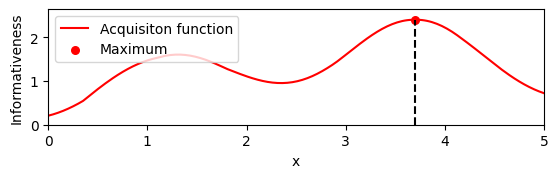

In [ ]:
num_steps = 6
for i in range(num_steps):
    # 1. evaluate the acquistion function
    ac = acquisition_function_upper_confidence_bound(model_mean, model_uncertainty)
    # 2. select the most informative next datapoint
    x_next, ac_next = select_experiment(gt_x, ac)
    # 3. "run the experiment"
    f_next = ground_truth(x_next)

    # 4. plot the results
    print(f"Iteration {i+1} of {num_steps}: New point: {x_next} {f_next}")
    plot(gt_x, gt_f, data_x, data_f, model_mean, model_uncertainty, ac = ac, x_next = x_next, ac_next = ac_next)

    # 5. add the new datapoint to the training data
    data_x = np.append(data_x, x_next)
    data_f = np.append(data_f, f_next)

    # 6. retrain the Gaussian process model
    gp_model = gp(kernel)
    gp_model.train(data_x.reshape(-1, 1), data_f.reshape(-1, 1))
    model_mean, model_uncertainty = gp_model.predict(gt_x)


**It works!**

The implementation here is just to show the basic principle of Bayesian optimization.

In reality, you would implement the Gaussian process model more efficiently, which is done in libraries such as **Ax and BoTorch**. This will be shown in the **next tutorial**.